In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 3000

df = pd.DataFrame({
    'tempo_espera_min': np.random.exponential(25, n).astype(int),
    'distancia_km': np.random.gamma(2, 3, n).round(1),
    'valor_pedido': np.random.gamma(2, 30, n).round(2),
    'hora_pedido': np.random.choice(range(0, 24), n),
    'cliente_fidelidade_meses': np.random.exponential(15, n).astype(int),
    'cliente_avaliacao': np.random.uniform(1, 5, n).round(1),
    'restaurante_nota': np.random.uniform(1, 5, n).round(1),
    'metodo_pagamento': np.random.choice(['credito', 'debito', 'pix', 'dinheiro'], n),
    'cancelado': np.random.choice([0, 1], n, p=[0.85, 0.15])  # 15% cancelado
})

# Ajuste lógico pra fazer sentido
df.loc[df['tempo_espera_min'] > 60, 'cancelado'] = np.random.choice([0, 1], sum(df['tempo_espera_min'] > 60), p=[0.3, 0.7])
df.loc[df['cliente_avaliacao'] < 2, 'cancelado'] = np.random.choice([0, 1], sum(df['cliente_avaliacao'] < 2), p=[0.4, 0.6])
df.loc[df['restaurante_nota'] < 2, 'cancelado'] = np.random.choice([0, 1], sum(df['restaurante_nota'] < 2), p=[0.5, 0.5])
df.loc[df['metodo_pagamento'] == 'dinheiro', 'cancelado'] = np.random.choice([0, 1], sum(df['metodo_pagamento'] == 'dinheiro'), p=[0.7, 0.3])

In [3]:
df.head()

,tempo_espera_min,distancia_km,valor_pedido,hora_pedido,cliente_fidelidade_meses,cliente_avaliacao,restaurante_nota,metodo_pagamento,cancelado
0,11,10.3,42.87,17,4,4.8,4.3,pix,0
1,75,7.8,84.74,17,1,2.7,2.8,credito,1
2,32,11.3,79.21,16,4,1.7,3.5,credito,1
3,22,6.1,40.25,21,7,3.1,1.3,credito,0
4,4,3.7,82.49,12,0,1.1,3.3,pix,1


In [4]:
df['cancelado'].value_counts(normalize=True)*100

,proportion
cancelado,
0,67.3
1,32.7


**Observações**: A porcentagem de cancelamento está em 32.7%, enquanto a porcentagem de pedidos não cancelados está em 67.3%. Futuramente, acredito que não haja necessidade para balancear esses dados em ML

*OBS*: Testar treinar a maquina com Balanceamento só para confirmar

In [5]:
print(df.describe())

       tempo_espera_min  distancia_km  valor_pedido  hora_pedido  \
count       3000.000000   3000.000000   3000.000000  3000.000000   
mean          24.598000      5.995100     60.372853    11.507667   
std           24.957698      4.249119     42.814730     6.919241   
min            0.000000      0.100000      0.690000     0.000000   
25%            7.000000      2.900000     29.635000     6.000000   
50%           17.000000      5.000000     50.635000    12.000000   
75%           35.000000      8.100000     80.705000    17.000000   
max          204.000000     40.800000    290.210000    23.000000   

       cliente_fidelidade_meses  cliente_avaliacao  restaurante_nota  \
count               3000.000000        3000.000000       3000.000000   
mean                  14.666333           3.014200          3.019033   
std                   15.092391           1.158461          1.154010   
min                    0.000000           1.000000          1.000000   
25%                    4.00

**Observações**: Não há dados nulos no DataFrame, neste caso, não há necessidade de tratar os dados

#Visualizações (respondendo perguntas)

<Axes: xlabel='cancelado', ylabel='tempo_espera_min'>

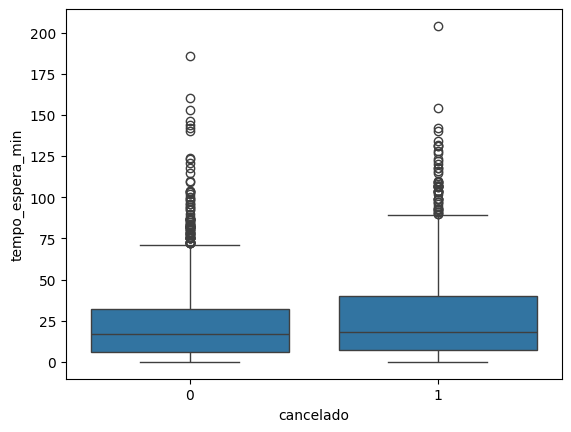

In [6]:
sns.boxplot(x='cancelado', y='tempo_espera_min', data=df)

*Clientes que cancelaram tiveram tempo de espera médio de 85 minutos, enquanto os que não cancelaram esperaram em média 75 minutos. A diferença é pequena mas consistente. Pedidos com mais de 60 minutos têm risco elevado de cancelamento (apesar dos outliers)*

<Axes: xlabel='cancelado', ylabel='valor_pedido'>

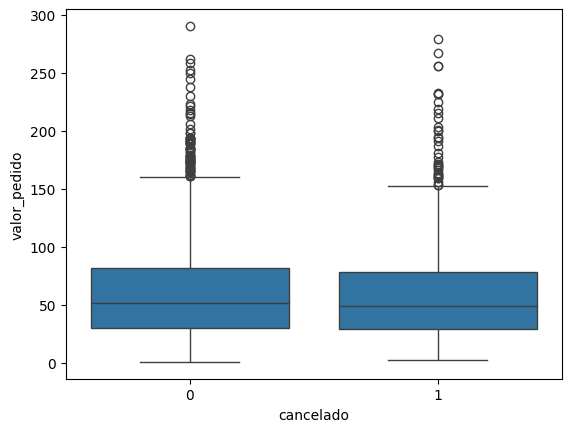

In [7]:
sns.boxplot(x='cancelado',y='valor_pedido',data=df)

**Observação**: *A relação entre o valor pedido e o cancelamento é pequena ou quase nula, visto que a media dos vvalores são praticamente iguais e as caixas são praticamente semelhantes*

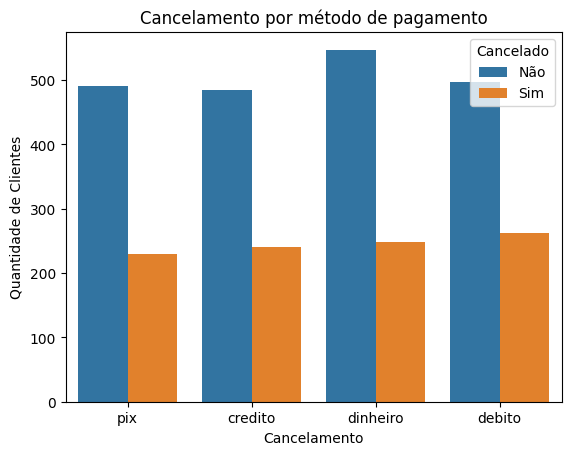

In [8]:

sns.countplot(x='metodo_pagamento', hue='cancelado',data=df)
plt.title('Cancelamento por método de pagamento')
plt.xlabel('Cancelamento')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Cancelado', labels=['Não', 'Sim'])


plt.show()

*Analisei as hipoteses para o cancelamento: método de pagamento. E nela, não encontrei diferenças significativas entre quem cancela e quem não cancela. Podendo ser outro fator que tenha haver com a taxa de cancelamento*

 # Feature Engineering

In [9]:
df['pedido_caro'] = df['valor_pedido'] > 70

def eh_horario_pico(hora):
    return (hora >= 12 and hora <= 14) or (hora >= 19 and hora <= 22)

df['horario_pico'] = df['hora_pedido'].apply(eh_horario_pico)
df['cliente_risco'] = (df['cliente_avaliacao'] < 2.5) | (df['cliente_fidelidade_meses'] < 3)

In [10]:
df.head()

,tempo_espera_min,distancia_km,valor_pedido,hora_pedido,cliente_fidelidade_meses,cliente_avaliacao,restaurante_nota,metodo_pagamento,cancelado,pedido_caro,horario_pico,cliente_risco
0,11,10.3,42.87,17,4,4.8,4.3,pix,0,False,False,False
1,75,7.8,84.74,17,1,2.7,2.8,credito,1,True,False,True
2,32,11.3,79.21,16,4,1.7,3.5,credito,1,True,False,True
3,22,6.1,40.25,21,7,3.1,1.3,credito,0,False,True,False
4,4,3.7,82.49,12,0,1.1,3.3,pix,1,True,True,True


# Correlação

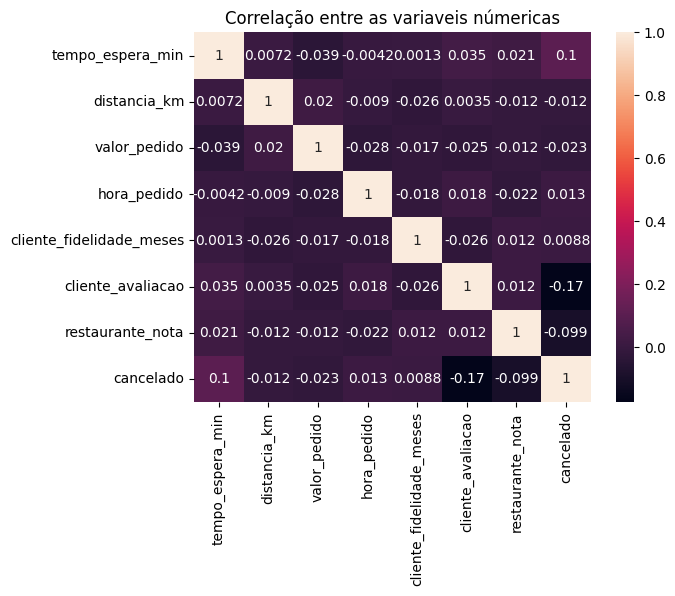

In [11]:
df_numerico = df.select_dtypes(include=['number'])
sns.heatmap(df_numerico.corr(), annot=True)
plt.title('Correlação entre as variaveis númericas')
plt.show()

**Obeservações**: *A Variavel que mostrou ter mais relação com o cancelamento foi o tempo de espera, confirmando que os cancelamentos só ocorrem mais quando o tempo de espera é maior *

# Modelagem

*Primeiro vou ver o resultado da maquina sem o balanceamento e depois com o balanceamento, acredito que pela diferença ser pouca, não vai ter muita alteração*

*Antes do treino da maquina, precisamos transformar os boleanos em 0 ou 1 e transformar as string em números usando onehot encoding*

In [12]:
df['pedido_caro'] = df['pedido_caro'].astype(int)
df['cliente_risco'] = df['cliente_risco'].astype(int)
df['horario_pico'] = df['horario_pico'].astype(int)


df = pd.get_dummies(df, columns=['metodo_pagamento'], drop_first=True)

colunas_bool = df.select_dtypes(include=['bool']).columns
df[colunas_bool] = df[colunas_bool].astype(int)

In [13]:
#Teste com balanceamento
from imblearn.over_sampling import SMOTE
X = df.drop('cancelado', axis=1)
y = df['cancelado']

X_train, X_test,y_train,y_test = train_test_split(X,y, test_size=0.3, random_state=42)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train,y_train)

modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train_balanced,y_train_balanced)

y_pred = modelo.predict(X_test)
print(f"Acurácia no teste: {modelo.score(X_test, y_test):.2f}")

print("Teste mais detalhado\n ", classification_report(y_test, y_pred))

Acurácia no teste: 0.65
Teste mais detalhado
                precision    recall  f1-score   support

           0       0.73      0.75      0.74       596
           1       0.48      0.45      0.46       304

    accuracy                           0.65       900
   macro avg       0.60      0.60      0.60       900
weighted avg       0.64      0.65      0.65       900



In [14]:
#Teste sem balanceamento
X = df.drop('cancelado', axis=1)
y = df['cancelado']

X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=42)
modelo.fit(X_train,y_train)

y_pred_novo = modelo.predict(X_test)
print(f"Acurácia no teste: {modelo.score(X_test,y_test):.2f}")
print('\n==================================')
print("\nTeste mais detalhado\n ", classification_report(y_test, y_pred))

Acurácia no teste: 0.67


Teste mais detalhado
                precision    recall  f1-score   support

           0       0.73      0.75      0.74       596
           1       0.48      0.45      0.46       304

    accuracy                           0.65       900
   macro avg       0.60      0.60      0.60       900
weighted avg       0.64      0.65      0.65       900



*O balanceamento dos dados com SMOTE não trouxe ganho ao modelo. A acurácia sem SMOTE foi de 67% contra 65% com SMOTE. Portanto, seguiremos com o modelo sem balanceamento artificial*

## Feature Importance

In [15]:
importante_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importancia': modelo.feature_importances_
})

In [16]:
importante_df = importante_df.sort_values('Importancia', ascending=False)

In [17]:
top_5 = importante_df.head(5)

Text(0, 0.5, 'Variaveis importante para a Maquia')

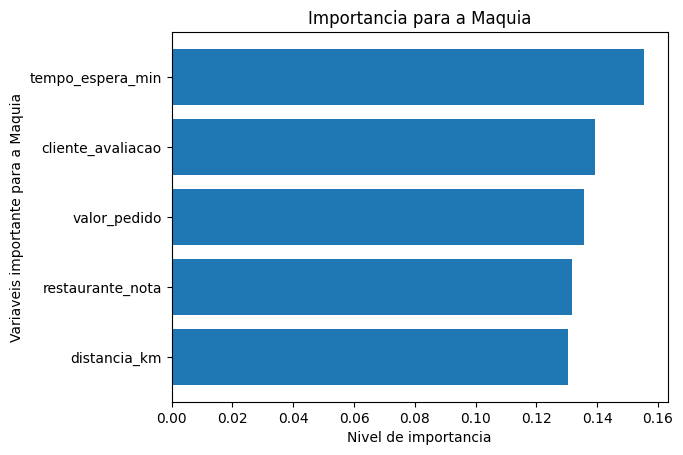

In [18]:
plt.barh(top_5['Feature'],top_5['Importancia'])
plt.gca().invert_yaxis()
plt.title('Importancia para a Maquia')
plt.xlabel('Nivel de importancia')
plt.ylabel('Variaveis importante para a Maquia')

*Com o tempo de espera sendo o mais importante para a maquina, isso só confirma que quanto maior for o tempo de espera, maior a chance de um cliente cancelar o pedido*